<a href="https://colab.research.google.com/github/Deep-Kamal/Placement/blob/main/Placement_Predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install opendatasets

In [3]:
import opendatasets as od

In [4]:
od.download("https://www.kaggle.com/datasets/somya2115/placement-csv")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: deepkamalgupta
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/somya2115/placement-csv


100%|██████████| 725/725 [00:00<00:00, 1.47MB/s]

In [11]:
import pandas as pd
import numpy as np

In [24]:
df = pd.read_csv('/content/placement-csv/placement.csv')

In [29]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [27]:
df.shape

(100, 4)

In [28]:
df = df.iloc[:,1:]

In [30]:
import matplotlib.pyplot as plt


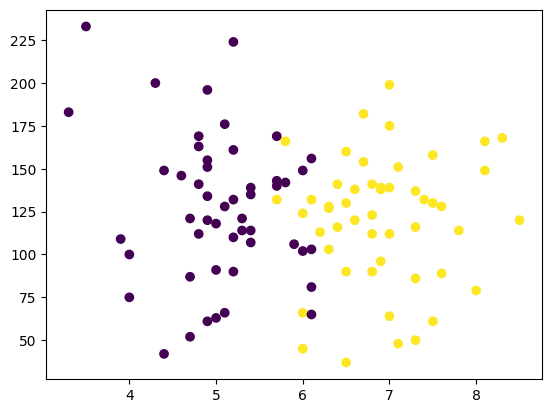

In [32]:
plt.scatter(df['cgpa'], df['iq'], c = df['placement'])

In [34]:
x = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [35]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [36]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [37]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.1)

In [38]:
x_train

,cgpa,iq
64,7.0,64.0
26,7.0,199.0
47,5.2,161.0
72,7.3,116.0
24,4.7,121.0
...,...,...
18,4.0,100.0
92,5.2,110.0
71,6.1,132.0
94,4.7,52.0


In [39]:
x_test

,cgpa,iq
31,3.9,109.0
93,6.8,112.0
77,7.3,50.0
74,6.7,154.0
59,4.8,112.0
61,7.3,137.0
60,6.9,139.0
99,6.2,113.0
42,7.6,89.0
85,5.8,166.0


In [40]:
y_train

,placement
64,1
26,1
47,0
72,1
24,0
...,...
18,0
92,0
71,1
94,0


In [41]:
y_test

,placement
31,0
93,1
77,1
74,1
59,0
61,1
60,1
99,1
42,1
85,1


In [42]:
from sklearn.preprocessing import StandardScaler

In [43]:
scale = StandardScaler()

In [48]:
x_train = scale.fit_transform(x_train)

In [49]:
x_train

array([[ 0.92399312, -1.48636044],
       [ 0.92399312,  1.84745521],
       [-0.66503964,  0.90904784],
       [ 1.18883192, -0.20222404],
       [-1.10643763, -0.07874939],
       [ 0.04119715, -1.95556413],
       [-0.04708245, -0.44917335],
       [-0.92987843, -1.56044523],
       [-1.01815803,  0.41514922],
       [ 0.65915433,  1.42764138],
       [ 0.12947674, -1.06654662],
       [-1.37127642,  0.61270867],
       [ 0.04119715, -0.54795307],
       [-0.75331923, -1.43697058],
       [-0.92987843,  0.66209853],
       [-1.37127642, -2.02964892],
       [ 0.30603594,  0.06942019],
       [ 1.01227272,  0.66209853],
       [-0.48848044,  0.36575936],
       [-0.75331923,  1.2794718 ],
       [ 0.30603594, -0.52325814],
       [ 0.48259513, -2.15312357],
       [-0.22364165,  0.39045429],
       [-0.84159883, -1.51105537],
       [ 0.39431554,  0.41514922],
       [-0.92987843,  0.76087825],
       [ 0.04119715,  0.61270867],
       [ 1.36539111,  0.14350499],
       [ 2.24818709,

In [50]:
x_test = scale.transform(x_test)

In [52]:
x_test

array([[-1.81267441, -0.37508856],
       [ 0.74743393, -0.30100377],
       [ 1.18883192, -1.83208947],
       [ 0.65915433,  0.73618332],
       [-1.01815803, -0.30100377],
       [ 1.18883192,  0.3163695 ],
       [ 0.83571353,  0.36575936],
       [ 0.21775634, -0.27630884],
       [ 1.45367071, -0.86898717],
       [-0.13536205,  1.03252249]])

In [57]:
from sklearn.linear_model import LogisticRegression

In [58]:
clf = LogisticRegression()

In [59]:
clf.fit(x_train, y_train)

LogisticRegression()

In [72]:
clf.predict(x_test)

array([0, 1, 1, 1, 0, 1, 1, 1, 1, 0])

In [73]:
y_test

,placement
31,0
93,1
77,1
74,1
59,0
61,1
60,1
99,1
42,1
85,1


In [83]:
from sklearn.metrics import accuracy_score

In [84]:
accuracy_score(y_test, y_pred)

0.9

In [85]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

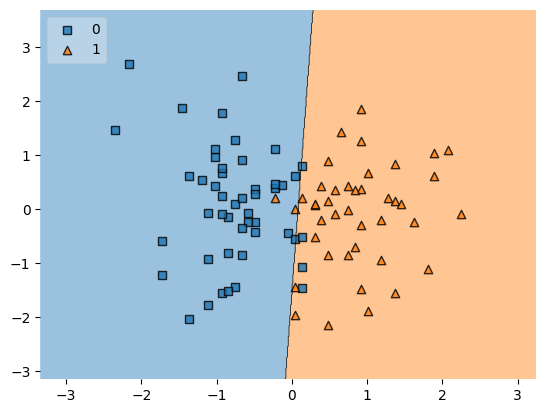

In [88]:
plot_decision_regions(x_train, y_train.values, clf=clf, legend=2)

In [91]:
import pickle

In [92]:
pickle.dump(df, open('model.pkl','wb'))